# 📊 E-Commerce Sales Exploratory Data Analysis (EDA)
**Objective:** To analyze sales data, understand customer purchasing behavior, and identify key areas for profit optimization.


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set aesthetic parameters for seaborn
sns.set_theme(style="whitegrid", palette="muted")


## 1. Data Loading and Inspection
In this section, we load the dataset and take a quick look at the first few rows, columns, and data types to understand its structure.


In [2]:
# Load the dataset (Make sure the CSV file is in the same folder as this notebook)
# Using 'windows-1252' encoding as it's common for Superstore datasets
try:
    df = pd.read_csv('Superstore.csv', encoding='mac_roman')
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("Error: Dataset file not found. Please check the file path.")

# Display the first 5 rows
df.head()


Dataset loaded successfully!


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
# Check dataset shape, columns, and data types
print(f"Dataset Shape: {df.shape}\n")
df.info()


Dataset Shape: (9800, 18)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-n

## 2. Data Cleaning & Preprocessing
Here we will handle missing values, drop irrelevant columns, and convert data types (like dates) to their proper formats for analysis.


In [4]:
# Check for missing values
print("Missing values in each column:\n", df.isnull().sum())

# Drop irrelevant columns (e.g., 'Row ID' doesn't add value to EDA)
if 'Row ID' in df.columns:
    df.drop('Row ID', axis=1, inplace=True)

# Convert 'Order Date' and 'Ship Date' to datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True, errors='coerce')

# Extract Year and Month for time-series analysis
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

print("\nData cleaning completed.")


Missing values in each column:
 Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

Data cleaning completed.


## 3. Exploratory Data Analysis (EDA)
Now, we will visualize the data to uncover trends and insights.

### 3.1. Top 10 Best-Selling Products
Which products generate the most revenue?


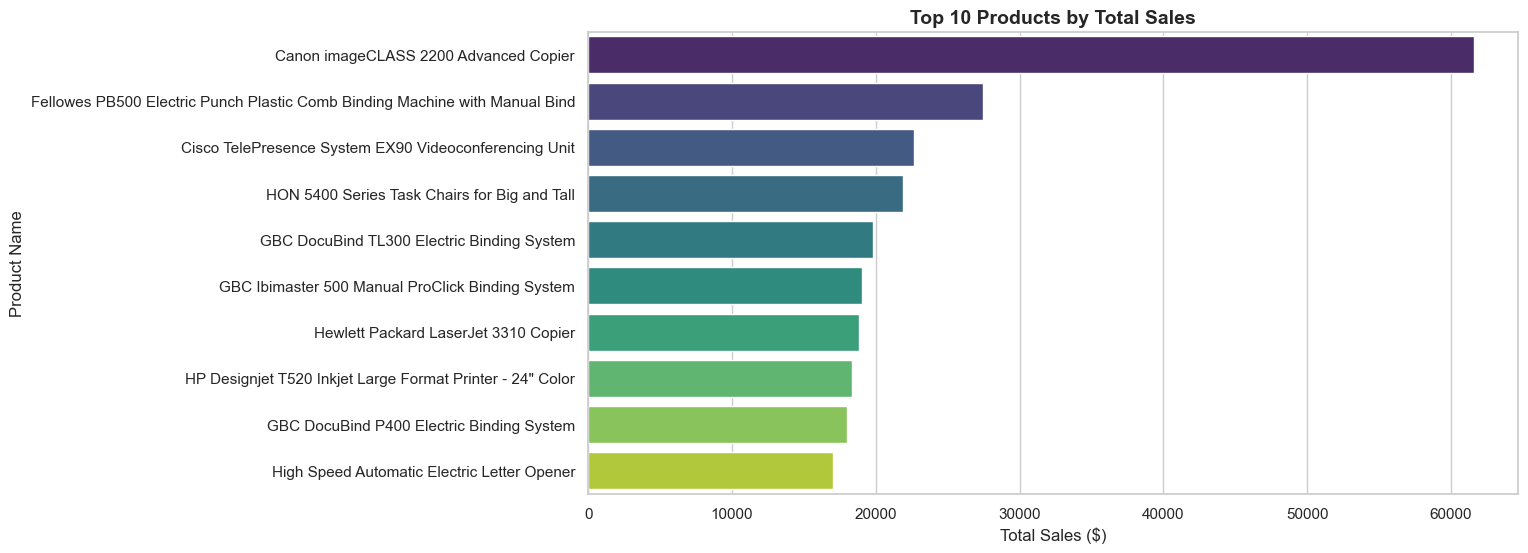

In [5]:
plt.figure(figsize=(12, 6))

# Group by product name and sum the sales, then get top 10
top_products = df.groupby('Product Name')['Sales'].sum().nlargest(10)

# Create bar plot
sns.barplot(x=top_products.values, y=top_products.index, palette='viridis')

plt.title('Top 10 Products by Total Sales', fontsize=14, fontweight='bold')
plt.xlabel('Total Sales ($)', fontsize=12)
plt.ylabel('Product Name', fontsize=12)
plt.show()


### 3.2. Sales Trend Over Time (Monthly)
How do sales perform across different months? Is there a seasonal trend?


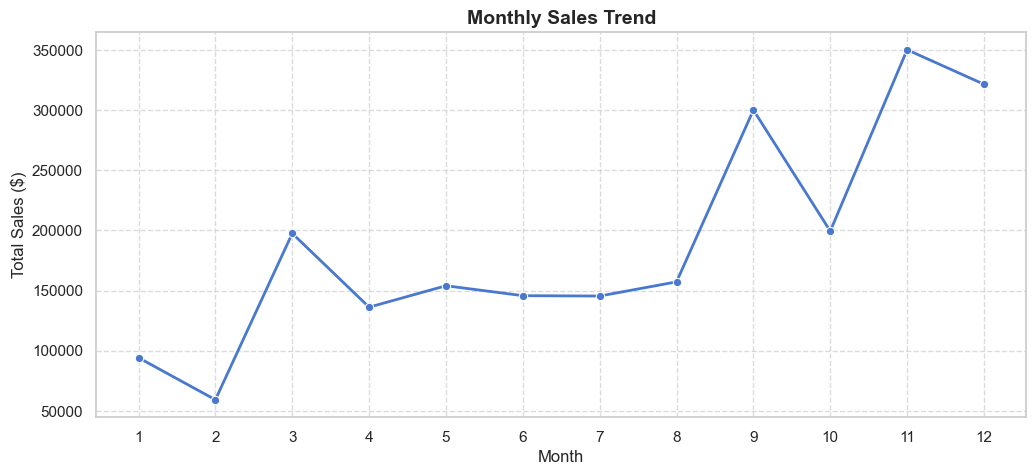

In [6]:
plt.figure(figsize=(12, 5))

# Group by month and sum the sales
monthly_sales = df.groupby('Month')['Sales'].sum().reset_index()

# Create line plot
sns.lineplot(x='Month', y='Sales', data=monthly_sales, marker='o', color='b', linewidth=2)

plt.title('Monthly Sales Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(range(1, 13)) # Ensure all 12 months are displayed
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


### 3.3. Sales by Product Category & Sub-Category
Since we don't have profit data, let's analyze which product categories and sub-categories are driving the most revenue for the business.


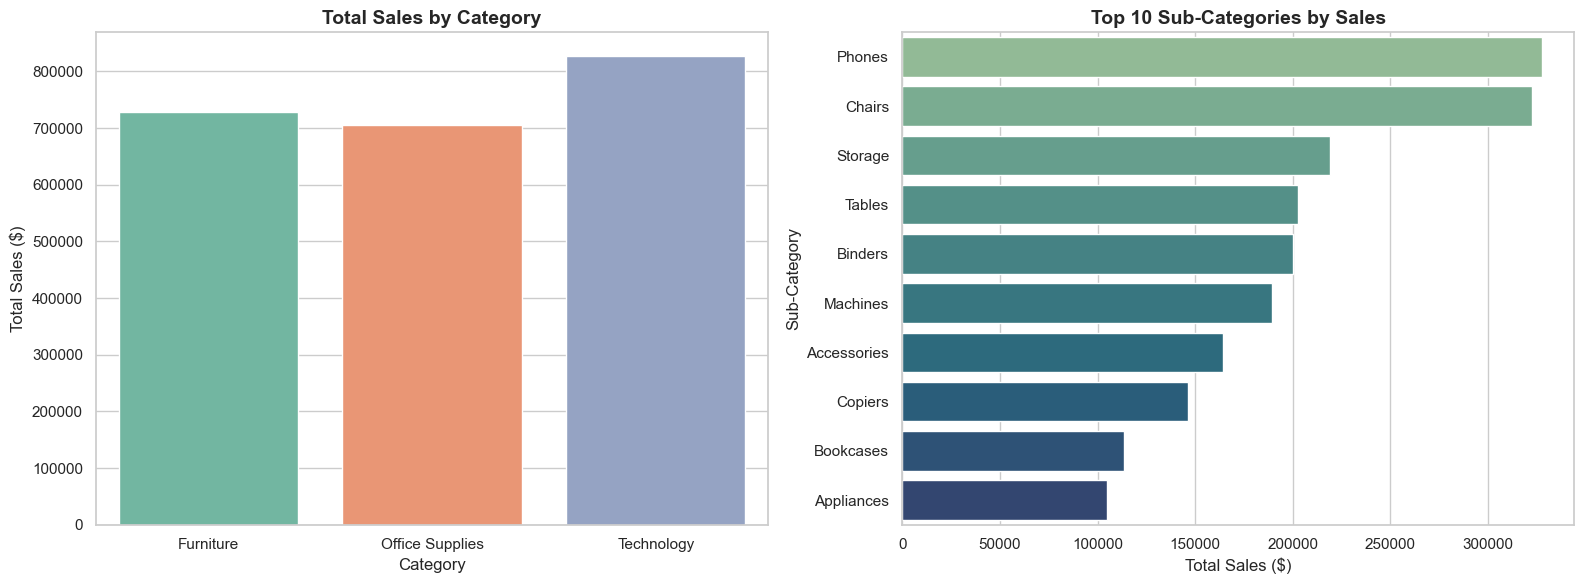

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Sales by Main Category
sns.barplot(x='Category', y='Sales', data=df, ax=axes[0], estimator=sum, errorbar=None, palette='Set2')
axes[0].set_title('Total Sales by Category', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Total Sales ($)', fontsize=12)
axes[0].set_xlabel('Category', fontsize=12)

# Plot 2: Top 10 Sub-Categories by Sales
top_subcat = df.groupby('Sub-Category')['Sales'].sum().nlargest(10).reset_index()
sns.barplot(x='Sales', y='Sub-Category', data=top_subcat, ax=axes[1], palette='crest')
axes[1].set_title('Top 10 Sub-Categories by Sales', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Total Sales ($)', fontsize=12)
axes[1].set_ylabel('Sub-Category', fontsize=12)

plt.tight_layout()
plt.show()


### 3.4. Regional Sales & Top Performing States
Where are our customers located? Let's break down the total sales by geographic region and state.


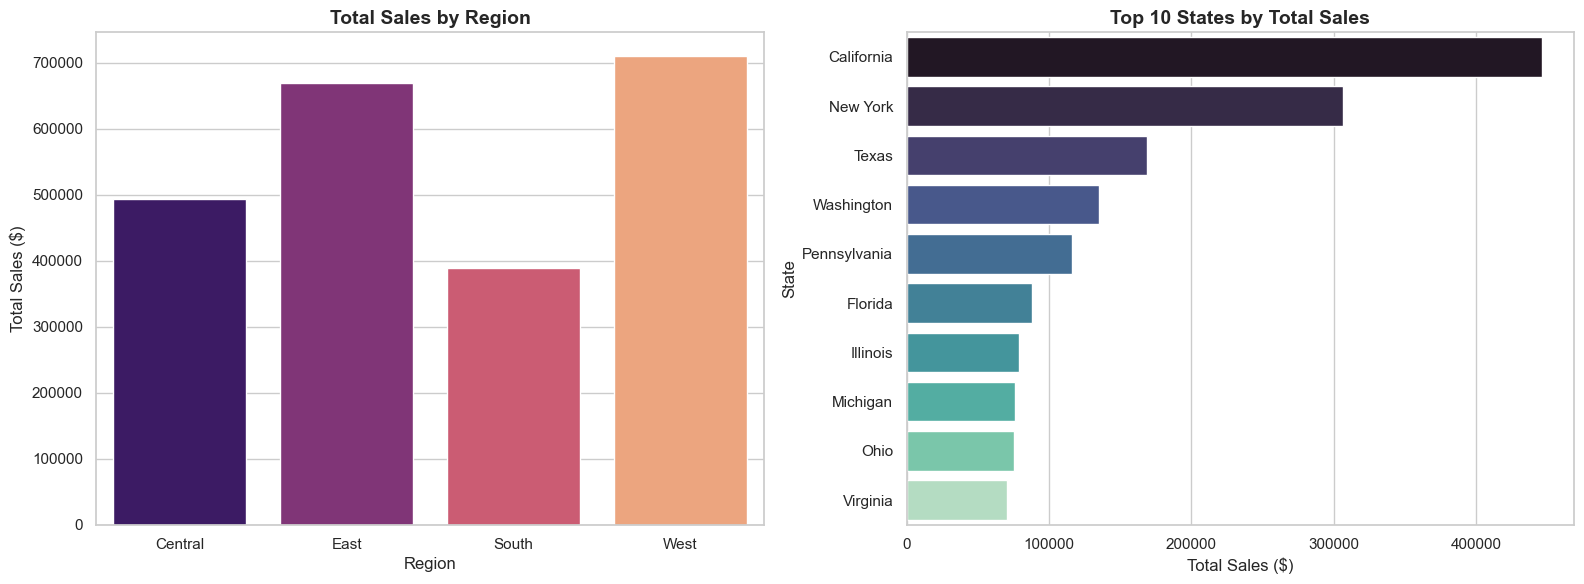

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Total Sales by Region
sales_by_region = df.groupby('Region')['Sales'].sum().reset_index()
sns.barplot(x='Region', y='Sales', data=sales_by_region, ax=axes[0], palette='magma')
axes[0].set_title('Total Sales by Region', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Total Sales ($)', fontsize=12)
axes[0].set_xlabel('Region', fontsize=12)

# Plot 2: Top 10 States by Sales
top_states = df.groupby('State')['Sales'].sum().nlargest(10).reset_index()
sns.barplot(x='Sales', y='State', data=top_states, ax=axes[1], palette='mako')
axes[1].set_title('Top 10 States by Total Sales', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Total Sales ($)', fontsize=12)
axes[1].set_ylabel('State', fontsize=12)

plt.tight_layout()
plt.show()


### 3.5. Customer Segments & Shipping Preferences
Finally, let's look at who is buying our products and how they prefer them to be shipped.


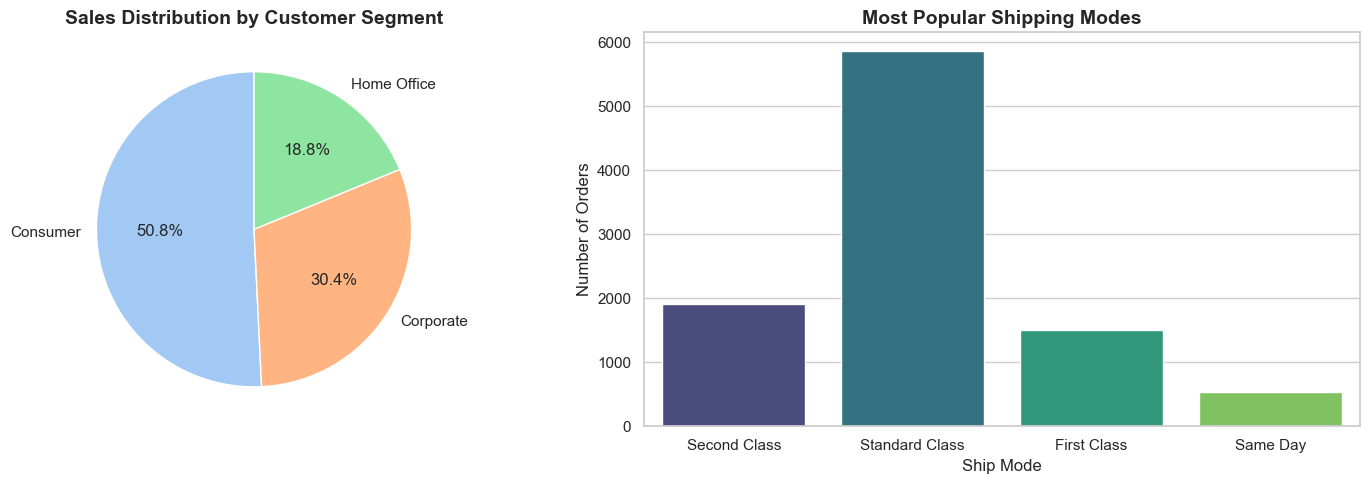

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Customer Segment share (Pie Chart)
segment_sales = df.groupby('Segment')['Sales'].sum()
axes[0].pie(segment_sales, labels=segment_sales.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'), startangle=90)
axes[0].set_title('Sales Distribution by Customer Segment', fontsize=14, fontweight='bold')

# Plot 2: Shipping Mode Preference (Count Plot)
sns.countplot(x='Ship Mode', data=df, ax=axes[1], palette='viridis')
axes[1].set_title('Most Popular Shipping Modes', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Orders', fontsize=12)
axes[1].set_xlabel('Ship Mode', fontsize=12)

plt.tight_layout()
plt.show()


# Top 5 Valuable Customers

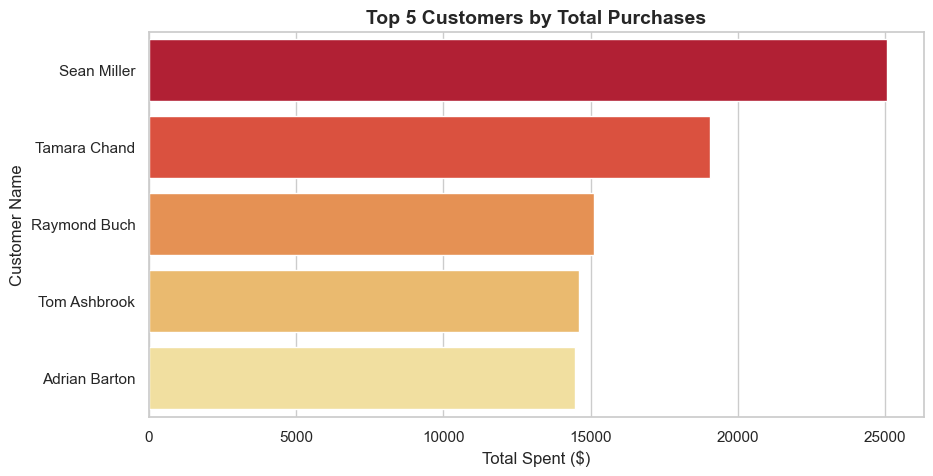

In [10]:

plt.figure(figsize=(10, 5))
top_customers = df.groupby('Customer Name')['Sales'].sum().nlargest(5).reset_index()

sns.barplot(x='Sales', y='Customer Name', data=top_customers, palette='YlOrRd_r')
plt.title('Top 5 Customers by Total Purchases', fontsize=14, fontweight='bold')
plt.xlabel('Total Spent ($)', fontsize=12)
plt.ylabel('Customer Name', fontsize=12)
plt.show()


#  Sales Distribution by Day of the Week



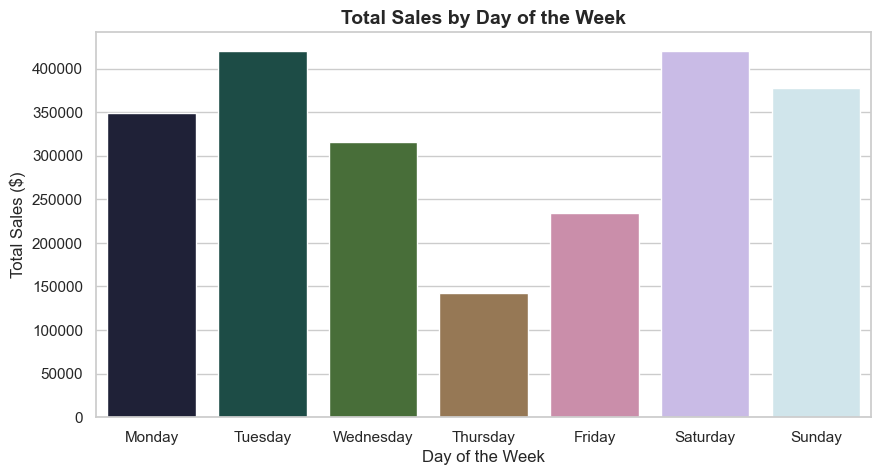

In [11]:
plt.figure(figsize=(10, 5))

# Extract day of the week from 'Order Date'
df['Day of Week'] = df['Order Date'].dt.day_name()

# Order the days logically
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Group by day and sum sales
daily_sales = df.groupby('Day of Week')['Sales'].sum().reindex(days_order).reset_index()

sns.barplot(x='Day of Week', y='Sales', data=daily_sales, palette='cubehelix')
plt.title('Total Sales by Day of the Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.show()


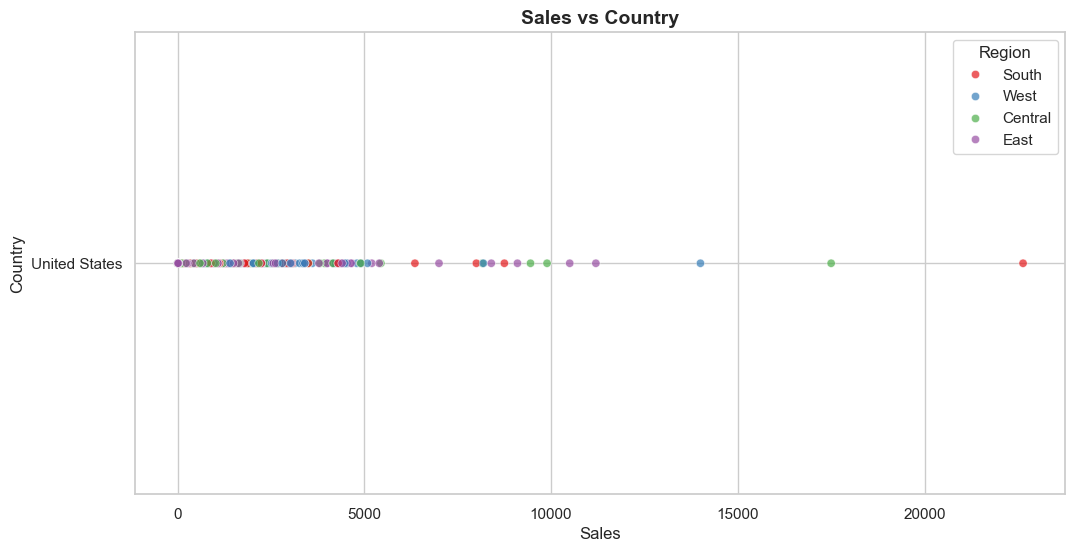

In [13]:
# show relationship between sales and country
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Sales', y='Country', data=df, hue='Region', palette='Set1', alpha=0.7)
plt.title('Sales vs Country', fontsize=14, fontweight='bold')
plt.xlabel('Sales', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.show()

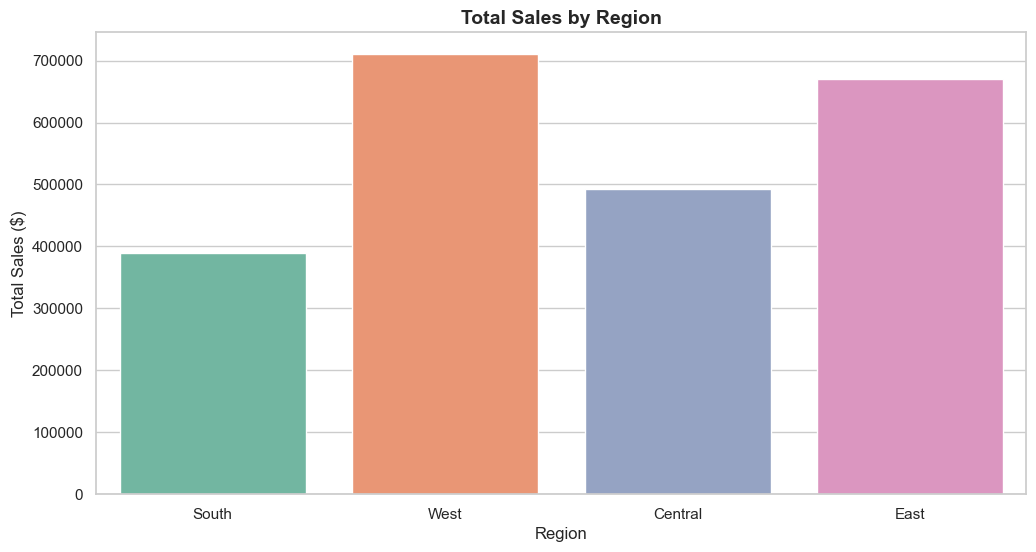

In [16]:
# show distribution of sales by region using bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x='Region', y='Sales', data=df, estimator=sum, errorbar=None, palette='Set2')
plt.title('Total Sales by Region', fontsize=14, fontweight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.show()